### Introduction

The Seoul Bike Sharing Demand dataset contains information on the number of bikes rented at different times of the day alongside weather and seasonal conditions. Bike demand can vary considerably depending on factors such as temperature, humidity, rainfall, snowfall, season, and time of day.

For a bike-sharing company, accurately predicting demand can help ensure that enough bikes are available when and where they are needed while reducing the problem of having too many unused bikes during periods of low demand.

In this project, we will explore the factors influencing bike rental demand and develop a regression model capable of predicting the number of bikes rented based on available weather, seasonal, and operational information.

### Objectives

The objectives of this project are to:

1. Explore the distribution and characteristics of bike rental demand.
2. Compare average bike rentals across different times of day and seasons.
3. Investigate the relationship between weather conditions and bike rental demand.
4. Determine which variables have the strongest relationship with the number of bikes rented.
5. Prepare the dataset for machine learning through appropriate data cleaning and preprocessing.
6. Develop regression models for predicting bike rental demand.
7. Evaluate and compare the performance of the regression models.
8. Identify the model that provides the most reliable predictions.

### Import the necesssary Python Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVC, SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

### Load the dataset

In [5]:
bike_df = pd.read_csv('SeoulBikeData.csv', encoding='cp1252')
bike_df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [6]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

There are no missing values in the data set but the categorical columns and data preprocessing steps still needs to be carried out.

In [7]:
bike_df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [8]:
bike_df.describe(include='object')

,Date,Seasons,Holiday,Functioning Day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


In [20]:
# Checking for duplicates
bike_df.duplicated().sum()

0

There are no duplicate values in the datasets

### Dealing with the Date Column

In [11]:
bike_df['Date'] = pd.to_datetime(bike_df['Date'], dayfirst=True)

In [13]:
bike_df['Month'] = bike_df['Date'].dt.month

In [14]:
bike_df['Year'] = bike_df['Date'].dt.year

In [15]:
bike_df.drop('Date', axis = 1)

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Month,Year
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,2017
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,2017
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,2017
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,2017
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes,11,2018
8756,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,11,2018
8757,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes,11,2018
8758,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes,11,2018


### Exploratory Data Analysis

#### 1. Correlation between Temperature and Bikes Rented

<Axes: xlabel='Temperature(°C)', ylabel='Rented Bike Count'>

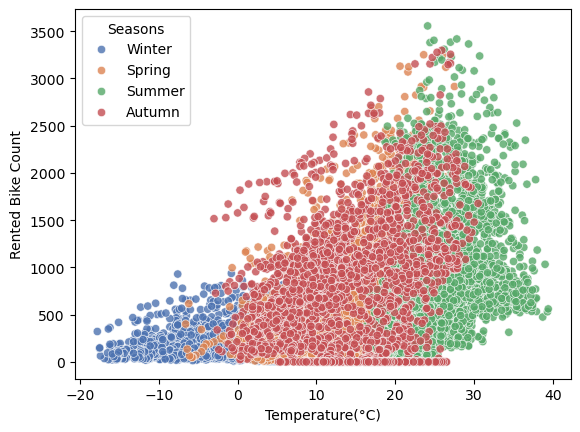

In [18]:
sns.scatterplot(bike_df, x='Temperature(°C)', y='Rented Bike Count', hue="Seasons", palette="deep", alpha=0.8)

In [17]:
correlation = bike_df[['Temperature(°C)', 'Rented Bike Count']].corr()
print(correlation)

                   Temperature(°C)  Rented Bike Count
Temperature(°C)           1.000000           0.538558
Rented Bike Count         0.538558           1.000000


Temperature has a moderate positive correlation with bike rentals **(r = 0.539)**. This indicates that bike demand generally increases as temperature rises. The scatter plot also shows this upward relationship, although there is considerable variation across seasons.

#### 2. Correlation Analysis

In [19]:
print(bike_df.corr(numeric_only=True)['Rented Bike Count'].sort_values(ascending=False))

Rented Bike Count            1.000000
Temperature(°C)              0.538558
Hour                         0.410257
Dew point temperature(°C)    0.379788
Solar Radiation (MJ/m2)      0.261837
Year                         0.215162
Visibility (10m)             0.199280
Month                        0.133514
Wind speed (m/s)             0.121108
Rainfall(mm)                -0.123074
Snowfall (cm)               -0.141804
Humidity(%)                 -0.199780
Name: Rented Bike Count, dtype: float64


Temperature (0.539) has the strongest positive correlation with bike demand, followed by Hour (0.410) and Dew Point Temperature (0.380).
Solar Radiation (0.262) and Visibility (0.199) show weak-to-moderate positive relationships.
Humidity (-0.200) has a weak negative relationship, suggesting that higher humidity is generally associated with slightly lower bike demand.
Snowfall (-0.142) and Rainfall (-0.123) also have weak negative relationships with demand.
Overall, temperature and time of day appear to be the most influential numerical factors associated with bike rental demand.

#### 3. Distribution of Rented Bikes

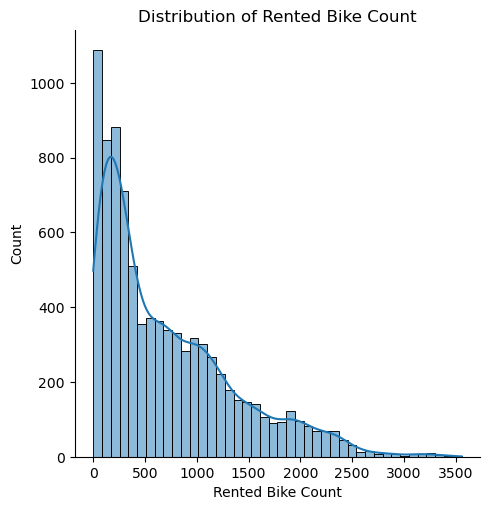

In [22]:
sns.displot(bike_df, x='Rented Bike Count', kde = True)
plt.title('Distribution of Rented Bike Count')
plt.show()

The distribution of Rented Bike Count is **right-skewed**, with most observations concentrated at relatively low rental counts and fewer observations at very high demand levels.
This suggests that bike demand varies considerably and may be worth considering when selecting and evaluating the regression model.

#### 4. Average Bike Rentals by Hour

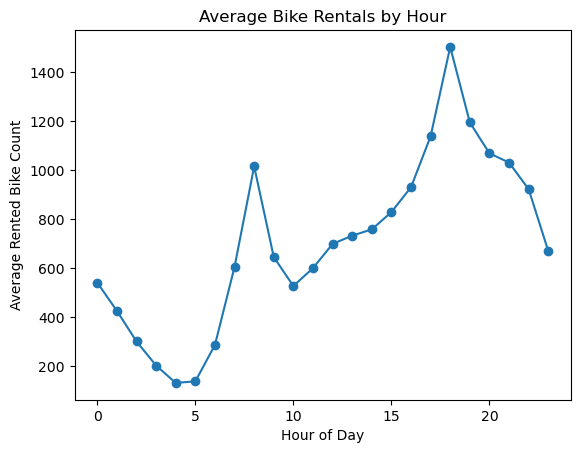

In [23]:
hourly_demand = bike_df.groupby('Hour')['Rented Bike Count'].mean()

hourly_demand.plot(kind='line', marker='o')
plt.title('Average Bike Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Rented Bike Count')
plt.show()

Demand is lowest during the early morning hours, particularly around 4–5 AM.
Demand begins increasing from around 6 AM, with a noticeable morning peak around 8 AM.
The highest demand occurs around 6 PM (18:00), after which rentals gradually decline.
This indicates that time of day is an important factor in predicting bike demand, likely reflecting commuting and daily activity patterns.

### Data Preprocessing

#### i. Dealing with categorical columns

In [ ]:
Date	Seasons	Holiday	Functioning Day

In [24]:
bike_df['Seasons'].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [25]:
bike_df['Seasons'] = bike_df['Seasons'].map({'Spring' : 0, 'Summer' : 1, 'Autumn' : 2, 'Winter' : 3})

In [26]:
bike_df['Holiday'].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [27]:
bike_df['Holiday'] = bike_df['Holiday'].map({'No Holiday' : 0, 'Holiday' : 1})

In [28]:
bike_df['Functioning Day'].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [29]:
bike_df['Functioning Day'] = bike_df['Functioning Day'].map({'No' : 0, 'Yes' : 1})

In [30]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   int64         
 12  Holida

### Splitting the data

In [34]:
# Features
X = bike_df.drop(['Rented Bike Count', 'Date'], axis = 1)

y = bike_df['Rented Bike Count']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)

In [36]:
print(X.shape, X_train.shape, X_test.shape)

(8760, 14) (7008, 14) (1752, 14)


### Scaling the Features

In [37]:
scaler = StandardScaler()

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

In [39]:
X_test_scaled = scaler.transform(X_test)

### Building the ML Model

#### a. Linear Regression Model

In [40]:
# Instantiate the model
ln_model = LinearRegression()

In [41]:
# Fit the model
ln_model.fit(X_train_scaled, y_train)

LinearRegression()

In [42]:
# Make predictions based on the training data
ln_model_pred = ln_model.predict(X_train_scaled)

In [103]:
# Evaluate the model performance on the training data
print('Linear Regression Training R2_score:', r2_score(y_train, ln_model_pred))
print('Linear Regression Training MSE:', mean_squared_error(y_train, ln_model_pred))
print('Linear Regression Training RSME:', root_mean_squared_error(y_train, ln_model_pred))

Linear Regression Training R2_score: 0.5482428100580764
Linear Regression Training MSE: 187744.21210673
Linear Regression Training RSME: 433.2946019819887


The Linear Regression model achieved an R² score of **0.548**, meaning that the model explains approximately 54.8% of the variation in bike rental demand in the training data. The training MSE was **187744.21**, with an RMSE of 433.29 bikes, indicating that the model's predictions deviate from the actual rental counts by approximately 433 bikes on average in terms of the RMSE measure.

In [104]:
# Using the testing set
ln_model_pred2 = ln_model.predict(X_test_scaled)
print('Linear Regression Testing R2_score:', r2_score(y_test, ln_model_pred2))
print('Linear Regression Testing MSE:', mean_squared_error(y_test, ln_model_pred2))
print('Linear Regression Training RSME:', root_mean_squared_error(y_test, ln_model_pred2))

Linear Regression Testing R2_score: 0.5243670800161737
Linear Regression Testing MSE: 198457.826464187
Linear Regression Training RSME: 445.48605641948774


On the unseen test data, the model achieved an R² score of **0.524**, explaining approximately 52.4% of the variation in bike demand. The test MSE increased slightly to **198457.83**, while the RMSE increased to 445.49 bikes. The relatively small difference between the training and testing R² scores (54.8% vs. 52.4%) indicates that the model generalizes reasonably well and does not show significant overfitting. 

However, the moderate R² score suggests that a simple linear relationship is not sufficient to fully capture the complex patterns in bike rental demand.

#### b. SVR Model

In [66]:
svr_model = SVR()

In [77]:
# Fit the model
svr_model.fit(X_train_scaled, y_train)

SVR()

In [88]:
# Making predictions on the training set
svr_training_pred = svr_model.predict(X_train_scaled)

In [89]:
# Evaluating the model performance on the training set
print('SVR Training R2 score:', r2_score(y_train, svr_training_pred))
print('SVR Training MSE:', mean_squared_error(y_train, svr_training_pred))
print('SVR Training RMSE:', root_mean_squared_error(y_train, svr_training_pred))

SVR Training R2 score: 0.39168303927812487
SVR Training MSE: 252808.34714898787
SVR Training RMSE: 502.8005043245162


The SVR model produced an R² score of **0.392**, meaning that it explains approximately 39.2% of the variation in bike rental demand in the training data. Its MSE was **252808.35**, with an RMSE of 502.80 bikes, which represents relatively large prediction errors compared with the other models.

In [78]:
# Making predictions
svr_model_pred = svr_model.predict(X_test_scaled)

In [101]:
# Evaluate the model performance
print('SVR Testing R2_score:', r2_score(y_test, svr_model_pred))
print('SVR Testing MSE:', mean_squared_error(y_test, svr_model_pred))
print('SVR Testing RMSE:', root_mean_squared_error(y_test, svr_model_pred))

SVR Testing R2_score: 0.40524069720479483
SVR Testing MSE: 248163.3073381578
SVR Testing RMSE: 498.15992144908427


On the test data, the SVR achieved an R² score of **0.405**, explaining approximately 40.5% of the variation in bike demand. Its MSE was **248163.31**, with an RMSE of 498.16 bikes. Interestingly, the testing performance was slightly better than the training performance, with the R² increasing from 0.392 to 0.405 and RMSE decreasing slightly. This does not indicate overfitting; rather, the model appears to generalize consistently but has relatively weak predictive performance. 

Overall, SVR was the weakest-performing model among the models evaluated.

#### c. Using Random Forest Regressor

In [56]:
forest_model = RandomForestRegressor()

In [57]:
# Fit the model
forest_model.fit(X_train, y_train)

RandomForestRegressor()

In [83]:
# Predicting on the training set
forest_training_pred = forest_model.predict(X_train)

In [90]:
# Evaluating model performance of the training set
print('Random Forest Training R2 score:', r2_score(y_train, forest_training_pred))
print('Random Forest Training MAE:', mean_squared_error(y_train, forest_training_pred))
print('Random Forest Training RSME:', root_mean_squared_error(y_train, forest_training_pred))

Random Forest Training R2 score: 0.9827631580504557
Random Forest Training MAE: 7163.3996825627855
Random Forest Training RSME: 84.63686952246512


The Random Forest model achieved an extremely high R² score of **0.983**, meaning that it explains approximately 98.3% of the variation in bike rental demand in the training data. The training MSE was only **7163.40**, resulting in an RMSE of 84.64 bikes. This indicates that the model fits the training data extremely well.

In [85]:
# Predicting using the test sets
forest_model_pred = forest_model.predict(X_test) 

In [102]:
# Evaluate the model performance on the testing set 
print('Random Forest R2 score:', r2_score(y_test, forest_model_pred))
print('Random Forest Testing MAE:', mean_squared_error(y_test, forest_model_pred))
print('Random Forest Testing RSME:', root_mean_squared_error(y_test, forest_model_pred))

Random Forest R2 score: 0.8872503559923364
Random Forest Testing MAE: 47044.786734132416
Random Forest Testing RSME: 216.89810219117274


On the test data, however, the R² decreased to **0.887**, while the MSE increased substantially to **47044.79** and the RMSE increased to 216.90 bikes. Despite this decrease from the training performance, the model still explains approximately 88.7% of the variation in unseen bike rental demand, which is substantially better than the other models. The difference between the training R² (98.3%) and testing R² (88.7%) suggests some degree of overfitting, but the model still demonstrates strong generalization and remains the best-performing model in this analysis.

#### d. Decision Tree Regressor Model

In [60]:
tree_model = DecisionTreeRegressor()

In [61]:
# Fit the model
tree_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [91]:
# Predicting based on the training set
tree_training_pred = tree_model.predict(X_train)

In [92]:
# Evaluating the model performance based on the training set
print('Decision Tree Training R2 Score:', r2_score(y_train, tree_training_pred))
print('Decision Tree Training MSE:', mean_squared_error(y_train, tree_training_pred))
print('Decision Tree Training RMSE:', root_mean_squared_error(y_train, tree_training_pred))

Decision Tree Training R2 Score: 1.0
Decision Tree Training MSE: 0.0
Decision Tree Training RMSE: 0.0


The Decision Tree achieved a perfect R² score of **1.000**, with an MSE and RMSE of **0.0**. This means the tree was able to perfectly reproduce the training observations. While this may initially appear ideal, it is actually a strong indication of overfitting, because a decision tree can become highly complex and essentially memorize the training data.

In [105]:
# Make predictions with the test sets
tree_model_pred = tree_model.predict(X_test)

In [97]:
# Evaluate the model performance
print('Decision Tree Testing R2 score:', r2_score(y_test, tree_model_pred))
print('Decision Tree Testing MSE:', mean_squared_error(y_test, tree_model_pred))
print('Decision Tree Testing RMSE:', root_mean_squared_error(y_test, tree_model_pred))

Decision Tree Testing R2 score: 0.7774985736361562
Decision Tree Testing MSE: 92838.71575342465
Decision Tree Testing RMSE: 304.6944629516996


When evaluated on unseen data, the R² dropped considerably to **0.777**, meaning that the model explains approximately 77.7% of the variation in bike rental demand. The test MSE was **92838.72**, with an RMSE of 304.69 bikes. The large difference between the training R² of 1.00 and testing R² of 0.777 confirms that the model has overfitted the training data. 

Nevertheless, its test performance is still considerably better than Linear Regression and SVR.

#### Overall Model Comparison

The results demonstrate a clear difference in model performance. SVR performed the weakest, while Linear Regression provided a reasonable baseline but was unable to capture the non-linear patterns in bike demand effectively. The Decision Tree performed considerably better but showed substantial overfitting, as demonstrated by its perfect training score and significantly lower test score. The Random Forest produced the best overall performance, achieving a testing R² of 0.887 and RMSE of 216.90 bikes. Although there is some evidence of overfitting due to the difference between its training and testing performance, its test results remain substantially stronger than those of the other models. 
Therefore, Random Forest Regressor is the most suitable model for the final analysis and prediction of Seoul bike rental demand among the models evaluated.

### Evaluating the feature importance

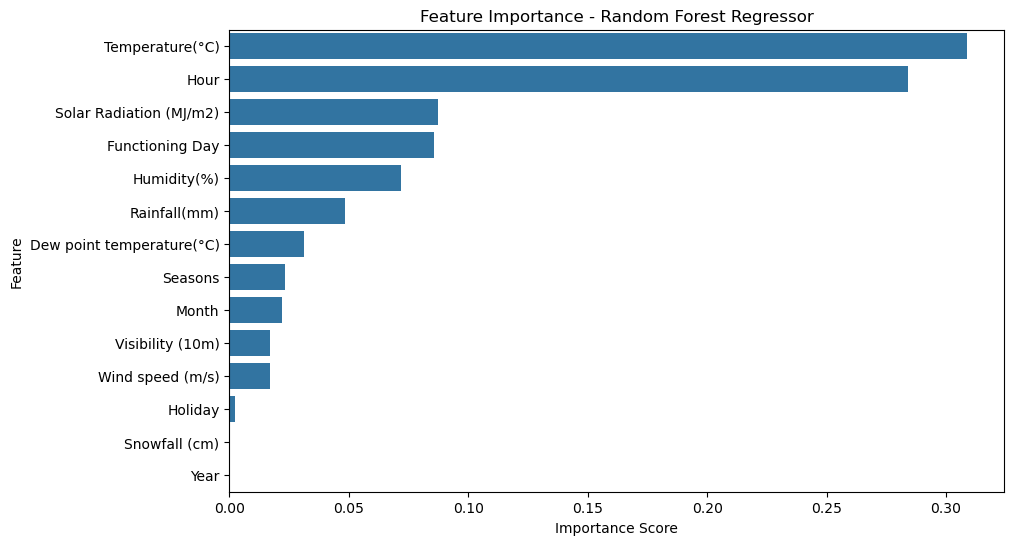

In [106]:
# Get feature importance
feature_importance = forest_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort from most to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the important features
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    order=importance_df['Feature']
)

plt.title('Feature Importance - Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()
